# Battery Report

Analysis of one or more CarbonShift solver battery runs.

Configure `RESULT_CSVS` in the next cell to point at the `battery_results_*.csv`
files you want to analyse.  All files are merged into a single DataFrame; a
`battery_id` column is added automatically from the file name.


In [51]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams["figure.dpi"] = 96
plt.style.use("seaborn-v0_8-whitegrid")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Configure these paths (absolute or relative to the notebook location) ──────

RESULT_CSVS: list[str | Path] = [
    "results/battery_results.csv",
]

# ────────────────────────────────────────────────────────────────────────────────

# Metrics to plot
METRICS: list[dict] = [
    {
        "col": "solver_time_ms_avg",
        "label": "Solver time (ms avg)",
        "color": "tab:blue",
    },
    {
        "col": "total_carbon_cost",
        "label": "Total carbon cost",
        "color": "tab:green",
    },
    {
        "col": "final_global_error",
        "label": "Final global error",
        "color": "tab:red",
    },
    {
        "col": "avg_global_error_per_slot",
        "label": "Avg global error / slot",
        "color": "tab:orange",
    },
    {
        "col": "carbon_cost_saving_vs_baseline_pct",
        "label": "Carbon saving vs baseline (%)",
        "color": "tab:purple",
    },
    {
        "col": "total_rollbacks",
        "label": "Total rollbacks (Rust only)",
        "color": "tab:brown",
    },
    {
        "col": "max_consecutive_rollbacks",
        "label": "Max consecutive rollbacks",
        "color": "tab:pink",
    },
]

MODE_STYLE: dict = {
    "greedy_fallback": {
        "linestyle": "-",
        "marker": "o",
    },
    "relaxed_retry": {
        "linestyle": "--",
        "marker": "s",
    },
}

BACKEND_COLOR: dict = {
    "python": {
        "greedy_fallback": "tab:blue",
        "relaxed_retry": "tab:cyan",
    },
    "rust": {
        "greedy_fallback": "tab:orange",
        "relaxed_retry": "tab:red",
    },
}

In [52]:
_nb_dir = Path(__file__) if "__file__" in dir() else Path.cwd()

frames = []

for p in RESULT_CSVS:
    p = Path(p) if not isinstance(p, Path) else p

    if not p.is_absolute():
        p = (_nb_dir / p).resolve()

    if not p.exists():
        raise FileNotFoundError(f"Results CSV not found: {p}")

    _df = pd.read_csv(p)

    # Derive battery_id from file stem:
    # battery_results_<id>.csv or battery_results.csv
    stem = p.stem  # e.g. "battery_results_run1"

    bid = stem.removeprefix("battery_results").lstrip("_") or "unnamed"

    _df.insert(0, "battery_id", bid)

    frames.append(_df)

df = pd.concat(frames, ignore_index=True)

df["batch_size"] = df["batch_size"].astype(int)

# Rollback columns may be absent in CSVs produced before the feature was added.
for _rb_col in (
    "total_rollbacks",
    "max_consecutive_rollbacks",
):
    if _rb_col not in df.columns:
        df[_rb_col] = 0

df["total_rollbacks"] = (
    df["total_rollbacks"]
    .fillna(0)
    .astype(int)
)

df["max_consecutive_rollbacks"] = (
    df["max_consecutive_rollbacks"]
    .fillna(0)
    .astype(int)
)

print(f"Loaded {len(df)} rows from {len(frames)} CSV file(s).")
print(f"Batteries   : {sorted(df['battery_id'].unique())}")
print(f"Scenarios   : {sorted(df['scenario_id'].unique())}")
print(f"Backends    : {sorted(df['backend'].unique())}")
print(f"Modes       : {sorted(df['infeasibility_mode'].unique())}")
print(f"Batch sizes : {sorted(df['batch_size'].unique())}")

df

Loaded 50 rows from 1 CSV file(s).
Batteries   : ['unnamed']
Scenarios   : ['high_load_105', 'high_load_38', 'high_load_56', 'high_load_74', 'high_load_92']
Backends    : ['rust']
Modes       : ['greedy_fallback', 'relaxed_retry']
Batch sizes : [np.int64(1), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]


,battery_id,scenario_id,backend,batch_size,infeasibility_mode,solver_time_ms_avg,total_carbon_cost,final_global_error,avg_global_error_per_slot,requests_assigned_with_greedy_fallback,requests_assigned_with_relaxed_retry,baseline_total_carbon_cost,carbon_cost_saving_vs_baseline_pct,total_rollbacks,max_consecutive_rollbacks
0,unnamed,high_load_38,rust,1,greedy_fallback,0.6306,8339.5730,3.9998,4.0003,0,0,33805.3664,75.3306,0,0
1,unnamed,high_load_38,rust,4,greedy_fallback,11.8880,7077.3004,3.9998,4.0097,0,0,33805.3664,79.0646,0,0
2,unnamed,high_load_38,rust,6,greedy_fallback,24.3564,6315.5935,3.9636,3.9569,0,0,33805.3664,81.3178,0,0
3,unnamed,high_load_38,rust,8,greedy_fallback,45.9246,5999.9169,3.9349,3.9457,0,0,33805.3664,82.2516,0,0
4,unnamed,high_load_38,rust,10,greedy_fallback,68.1409,6679.0651,3.9079,3.8992,0,0,33805.3664,80.2426,0,0
5,unnamed,high_load_38,rust,1,relaxed_retry,1.0498,8387.6435,3.9969,3.9938,0,35,33805.3664,75.1884,0,0
6,unnamed,high_load_38,rust,4,relaxed_retry,12.7003,5784.7382,3.9992,4.0081,0,23,33805.3664,82.8881,0,0
7,unnamed,high_load_38,rust,6,relaxed_retry,26.1376,6377.4923,3.9768,3.9663,0,756,33805.3664,81.1347,0,0
8,unnamed,high_load_38,rust,8,relaxed_retry,44.3205,6511.8339,3.9533,3.9448,0,845,33805.3664,80.7373,0,0
9,unnamed,high_load_38,rust,10,relaxed_retry,72.4760,7349.4506,3.9211,3.9132,0,936,33805.3664,78.2595,0,0


## Execution timings

Wall-clock time per scenario and total battery run time, read from
`battery_timings_*.csv` files that mirror the `RESULT_CSVS` list above.


In [53]:
# Derive timing CSV paths from RESULT_CSVS (battery_results_X.csv → battery_timings_X.csv)
timing_frames = []
for p in RESULT_CSVS:
    p = Path(p) if not isinstance(p, Path) else p
    if not p.is_absolute():
        p = (_nb_dir / p).resolve()
    stem = p.stem  # e.g. "battery_results_run1"
    bid = stem.removeprefix("battery_results").lstrip("_") or "unnamed"
    timing_path = p.parent / f"battery_timings{('_' + bid) if bid != 'unnamed' else ''}.csv"
    if not timing_path.exists():
        print(f"WARNING: timing file not found: {timing_path}")
        continue
    _t = pd.read_csv(timing_path)
    _t.insert(0, "battery_id", bid)
    timing_frames.append(_t)

if not timing_frames:
    print("No timing files found – run the battery first to generate timings.")
else:
    tdf = pd.concat(timing_frames, ignore_index=True)

    # Separate per-scenario rows from the battery total
    scenario_times = tdf[tdf["scenario_id"] != "__battery_total__"].copy()
    battery_totals = tdf[tdf["scenario_id"] == "__battery_total__"].copy()

    battery_ids = scenario_times["battery_id"].unique().tolist()
    n_batteries = len(battery_ids)

    fig, axes = plt.subplots(1, n_batteries, figsize=(max(7, 5 * n_batteries), 4.5), squeeze=False)

    for ax, bid in zip(axes[0], battery_ids):
        sub = scenario_times[scenario_times["battery_id"] == bid].sort_values("scenario_id")
        total_row = battery_totals[battery_totals["battery_id"] == bid]
        total_s = float(total_row["elapsed_seconds"].iloc[0]) if not total_row.empty else sub["elapsed_seconds"].sum()

        bars = ax.barh(sub["scenario_id"], sub["elapsed_seconds"], color="tab:steelblue", edgecolor="white")
        for bar, val in zip(bars, sub["elapsed_seconds"]):
            ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}s", va="center", fontsize=9)

        ax.set_xlabel("Wall-clock time (seconds)")
        ax.set_title(
            f"Battery: {bid}\nTotal: {total_s:.1f}s",
            fontsize=11, fontweight="bold",
        )
        ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nPer-battery totals:")
    for bid in battery_ids:
        total_row = battery_totals[battery_totals["battery_id"] == bid]
        if not total_row.empty:
            print(f"  {bid}: {float(total_row['elapsed_seconds'].iloc[0]):.1f}s")


No timing files found – run the battery first to generate timings.


## Per-scenario metrics

One figure per scenario.  Each figure shows all metrics; lines are split by
`(backend, infeasibility_mode)` combination.


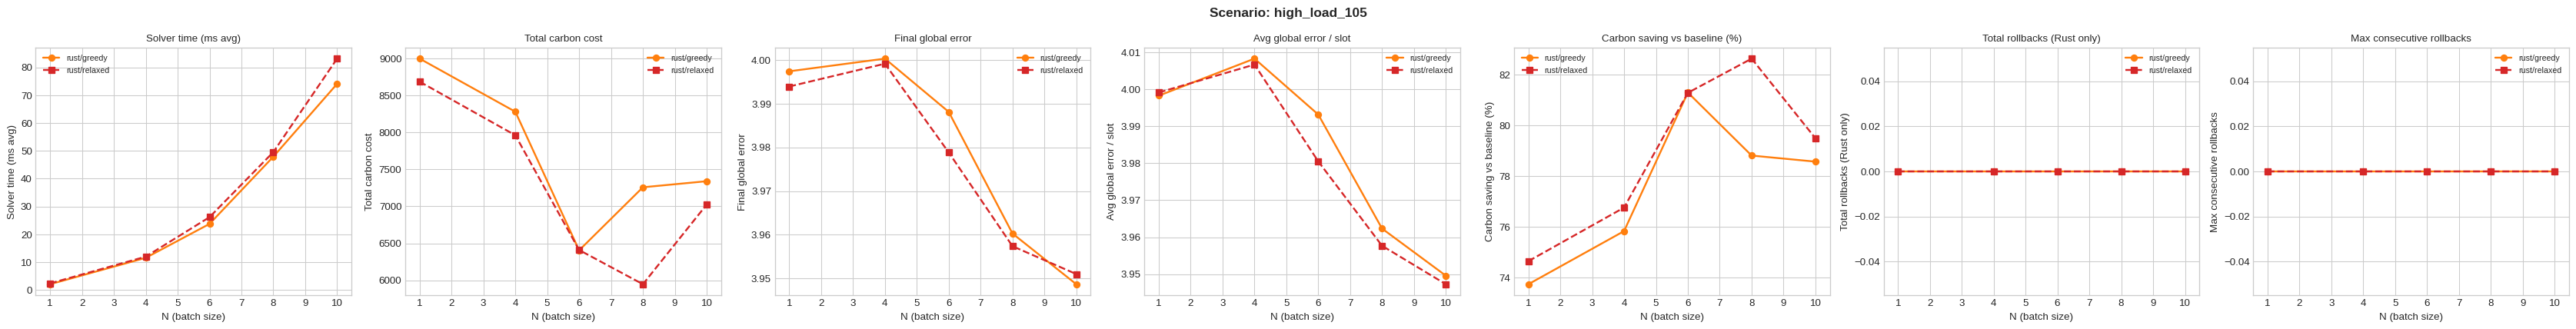

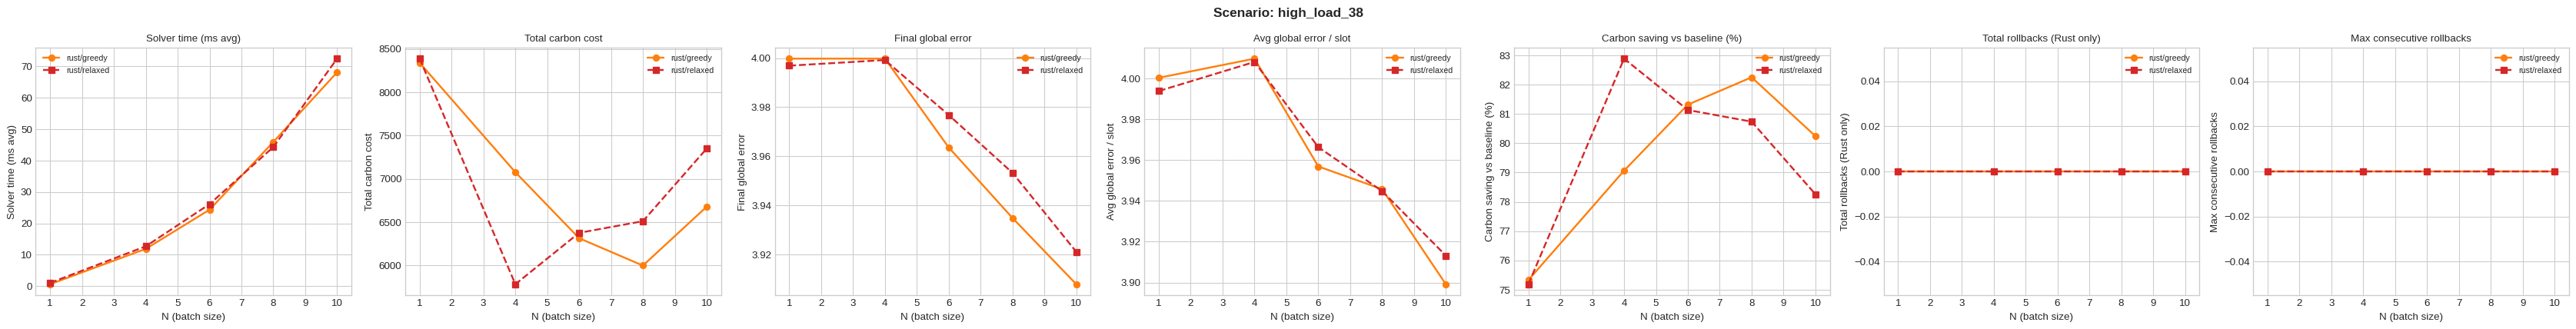

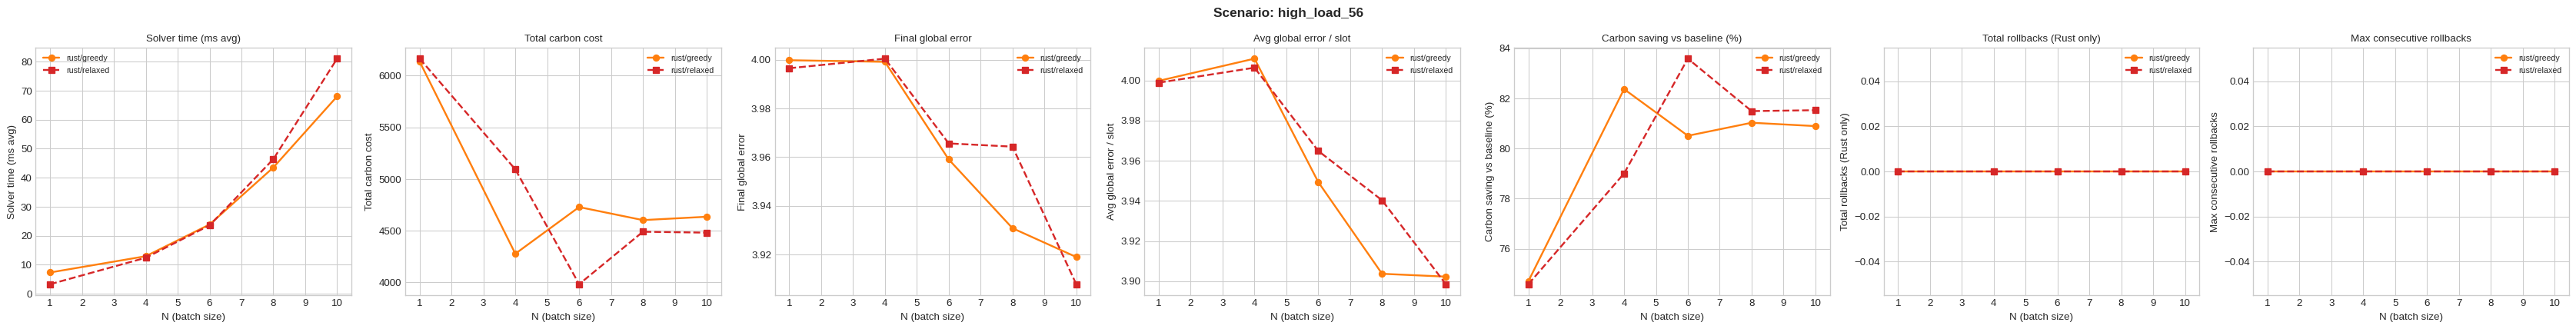

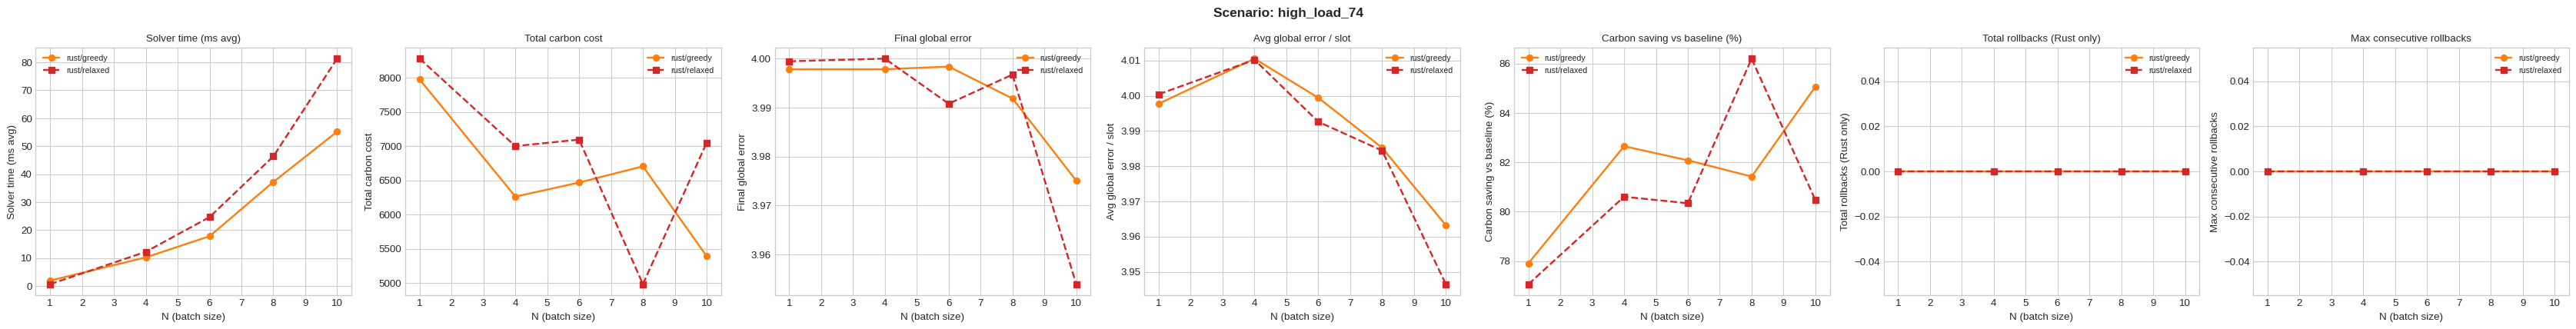

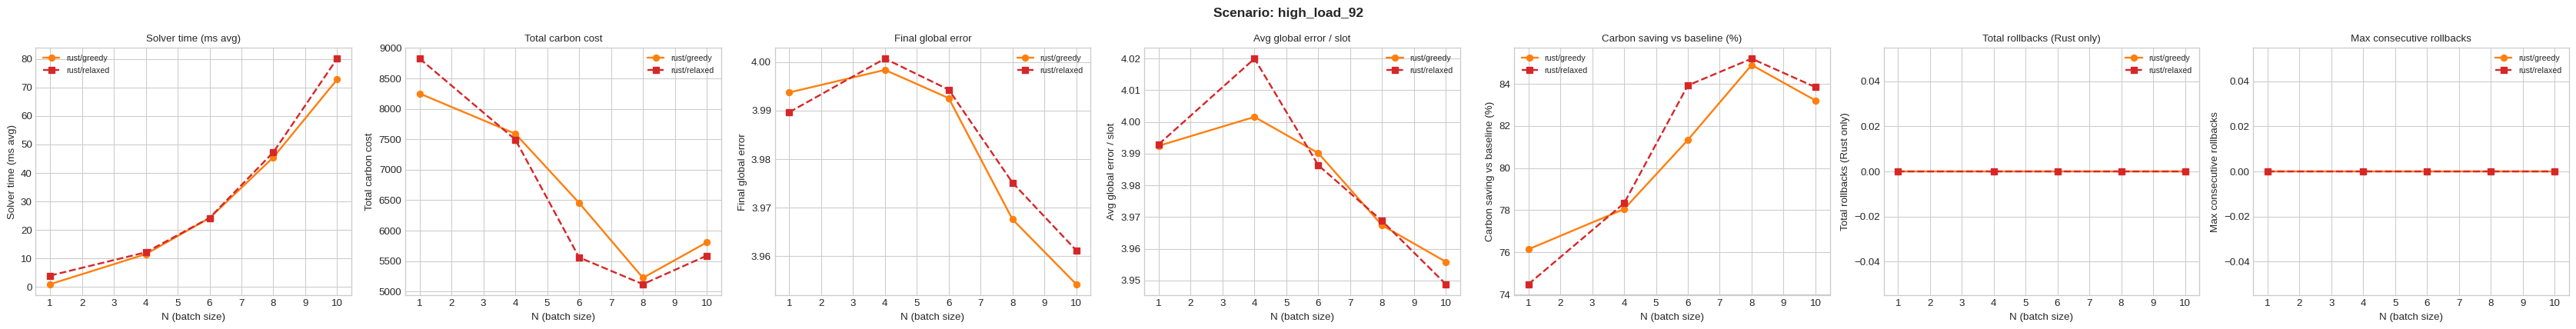

In [54]:
def _series_label(backend: str, mode: str) -> str:
    mode_short = "greedy" if mode == "greedy_fallback" else "relaxed"
    return f"{backend}/{mode_short}"

def _series_style(backend: str, mode: str) -> dict:
    color = BACKEND_COLOR.get(backend, {}).get(mode, "gray")
    style = MODE_STYLE.get(mode, {})
    return {"color": color, **style}

scenarios = sorted(df["scenario_id"].unique())
combos = sorted(
    df[["backend", "infeasibility_mode"]].drop_duplicates().itertuples(index=False, name=None)
)
n_metrics = len(METRICS)

for sid in scenarios:
    s_df = df[df["scenario_id"] == sid].sort_values("batch_size")
    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 4.5))
    if n_metrics == 1:
        axes = [axes]
    fig.suptitle(f"Scenario: {sid}", fontsize=13, fontweight="bold")

    for ax, m in zip(axes, METRICS):
        for backend, mode in combos:
            sub = s_df[(s_df["backend"] == backend) & (s_df["infeasibility_mode"] == mode)]
            if sub.empty:
                continue
            label = _series_label(backend, mode)
            style = _series_style(backend, mode)
            ax.plot(sub["batch_size"], sub[m["col"]], label=label, linewidth=1.8, **style)
        ax.set_xlabel("N (batch size)")
        ax.set_ylabel(m["label"])
        ax.set_title(m["label"], fontsize=10)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.legend(fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()


## All scenarios on one chart

Each metric is shown in a single figure with one subplot per `(backend, infeasibility_mode)`
combination.  All scenarios appear as separate lines to allow direct comparison.


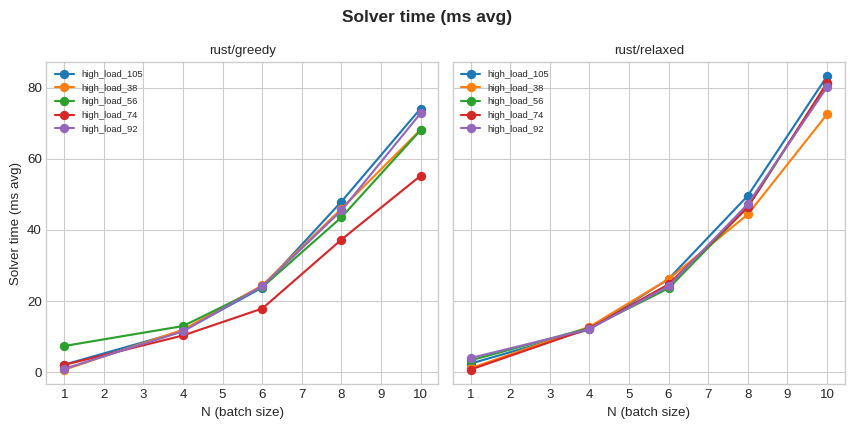

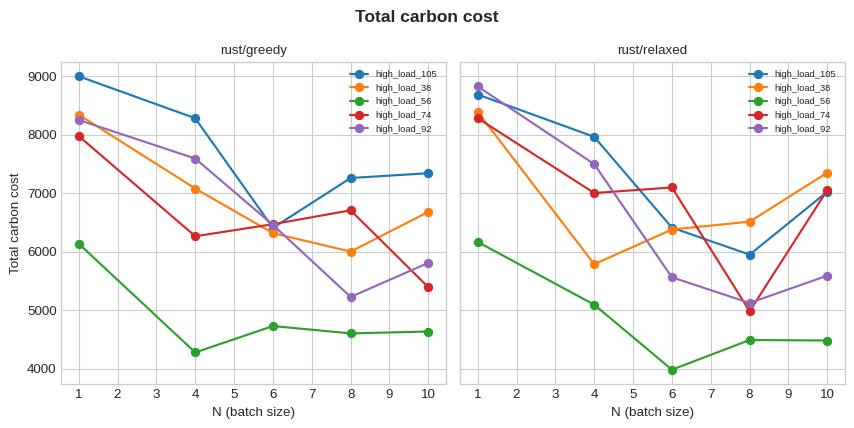

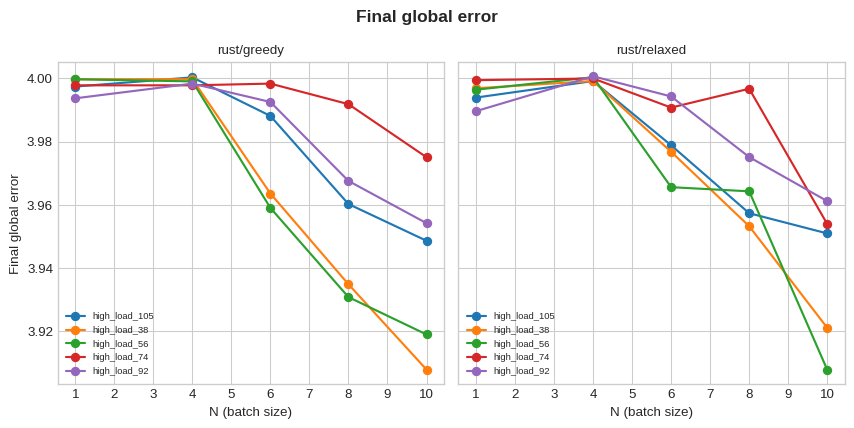

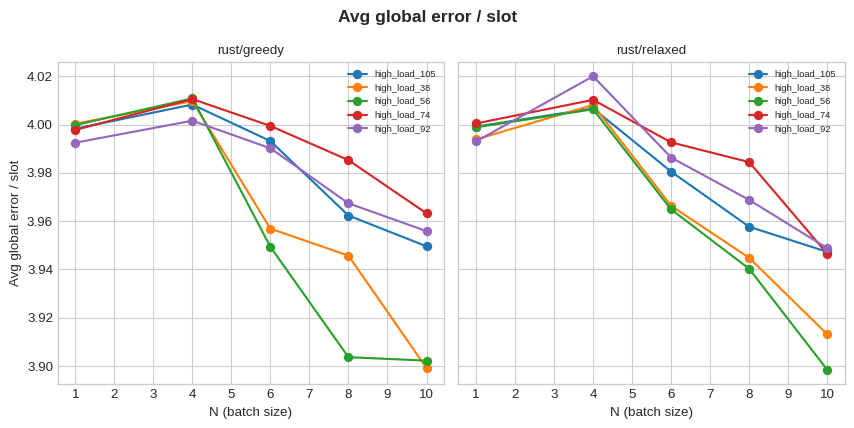

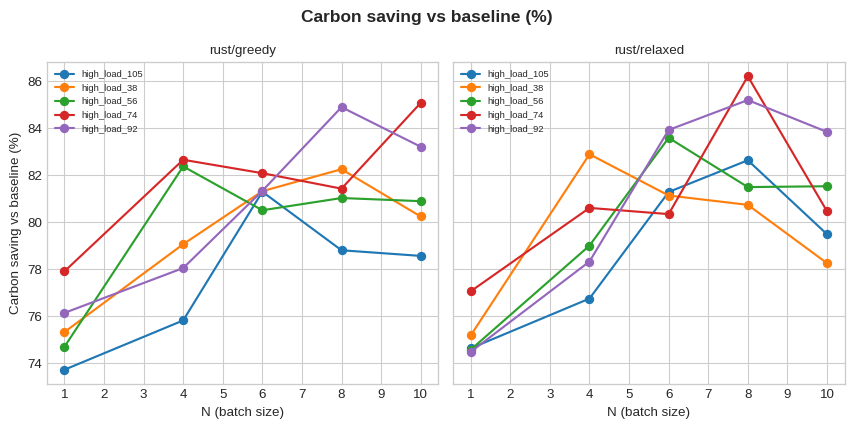

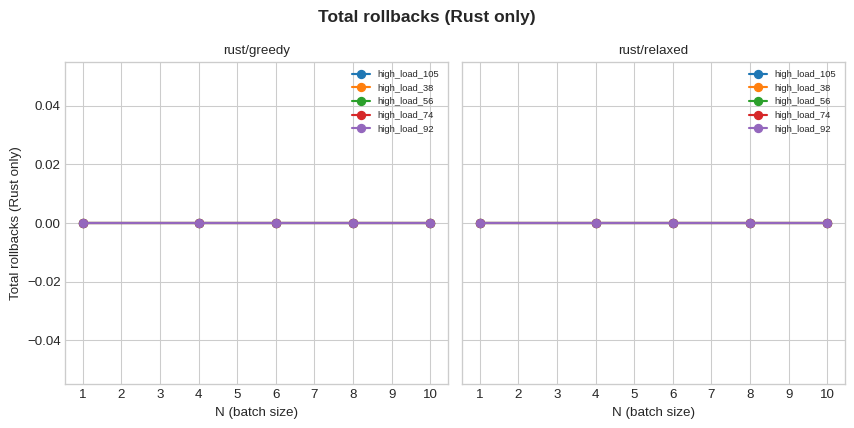

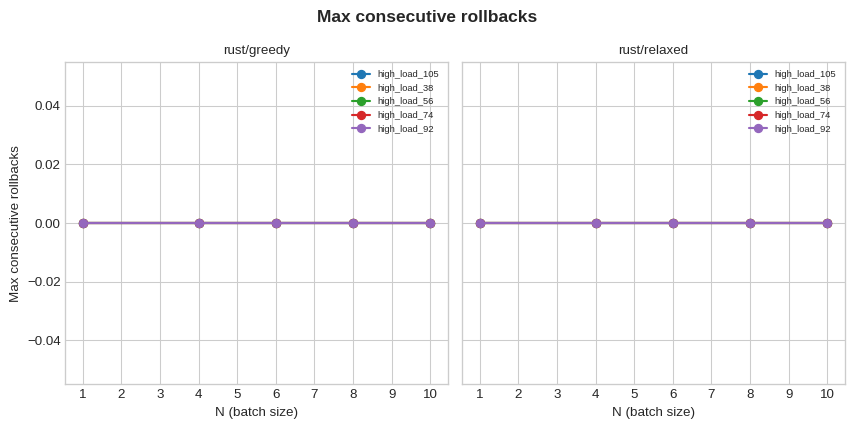

In [55]:
fig_w = max(6, 4.5 * len(combos))
for m in METRICS:
    fig, axes = plt.subplots(1, len(combos), figsize=(fig_w, 4.5), sharey=True)
    if len(combos) == 1:
        axes = [axes]
    fig.suptitle(m["label"], fontsize=13, fontweight="bold")

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    sid_color = {sid: colors[i % len(colors)] for i, sid in enumerate(scenarios)}

    for ax, (backend, mode) in zip(axes, combos):
        ax.set_title(_series_label(backend, mode), fontsize=10)
        ax.set_xlabel("N (batch size)")
        if ax is axes[0]:
            ax.set_ylabel(m["label"])
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

        for sid in scenarios:
            sub = df[
                (df["scenario_id"] == sid) &
                (df["backend"] == backend) &
                (df["infeasibility_mode"] == mode)
            ].sort_values("batch_size")
            if sub.empty:
                continue
            ax.plot(sub["batch_size"], sub[m["col"]],
                    marker="o", linewidth=1.6, color=sid_color[sid],
                    label=sid)

        ax.legend(fontsize=7, loc="best")

    plt.tight_layout()
    plt.show()


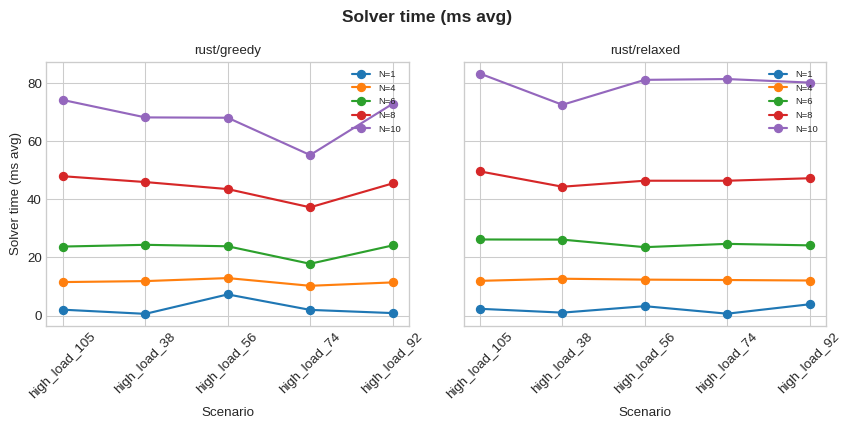

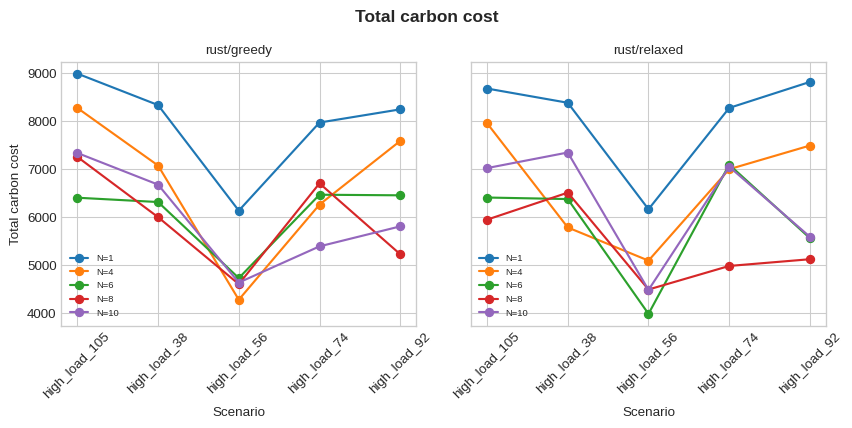

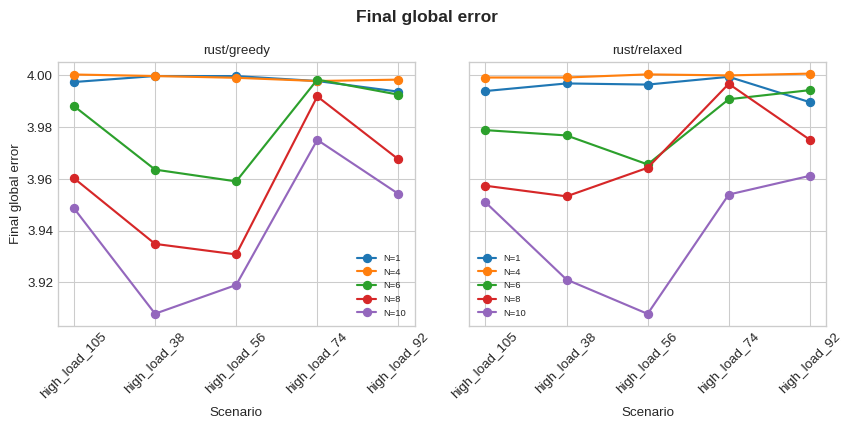

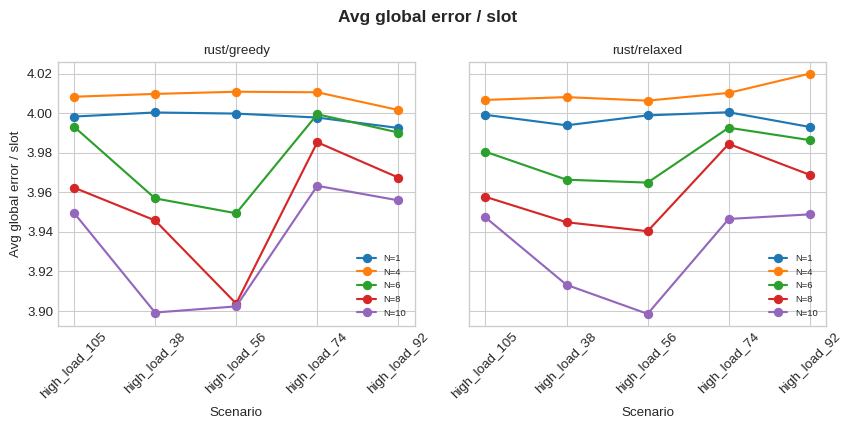

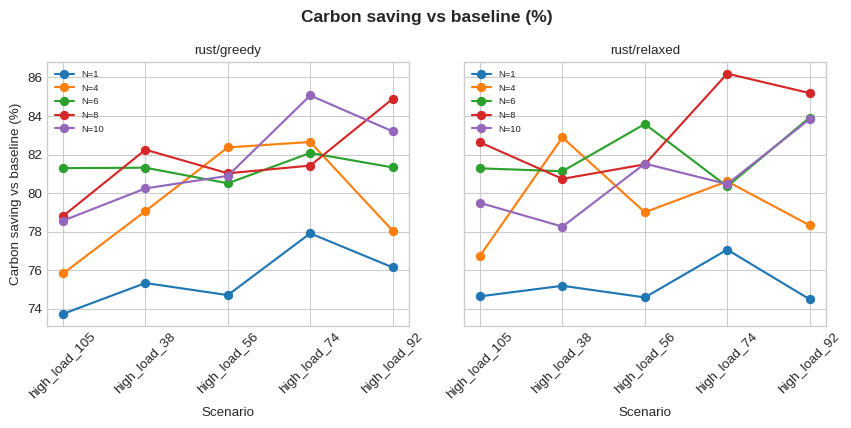

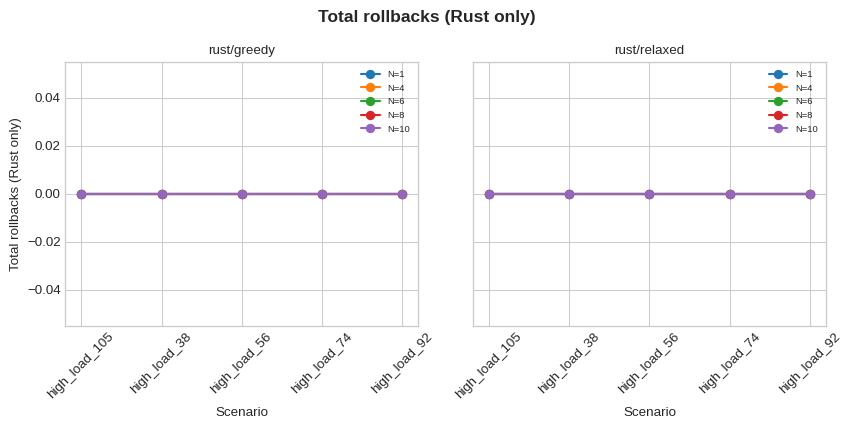

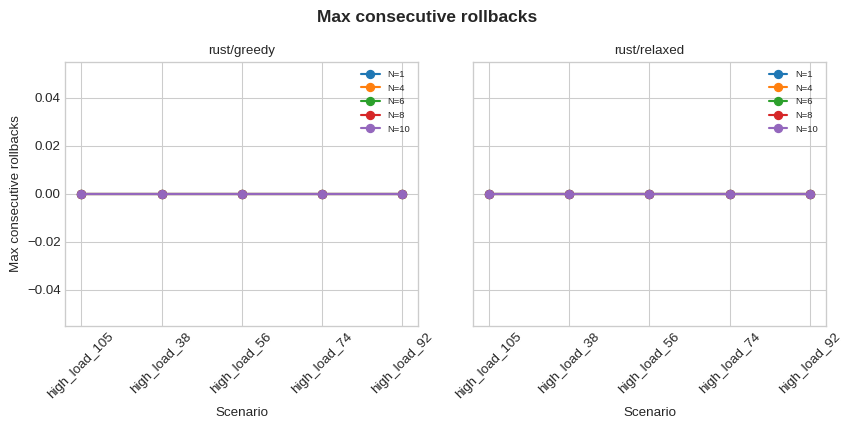

In [56]:
fig_w = max(6, 4.5 * len(combos))

fig_w = max(6, 4.5 * len(combos))

for m in METRICS:

    fig, axes = plt.subplots(
        1,
        len(combos),
        figsize=(fig_w, 4.5),
        sharey=True
    )

    if len(combos) == 1:
        axes = [axes]

    fig.suptitle(m["label"], fontsize=13, fontweight="bold")

    for ax, (backend, mode) in zip(axes, combos):

 
       ax.set_title(_series_label(backend, mode), fontsize=10)
       ax.set_xlabel("Scenario")
       if ax is axes[0]:
           ax.set_ylabel(m["label"])
    
       # dati del pannello corrente
       panel_df = df[
           (df["backend"] == backend) &
           (df["infeasibility_mode"] == mode)
       ]
    
       batch_sizes = sorted(panel_df["batch_size"].unique())
    
       colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
       bs_color = {
           bs: colors[i % len(colors)]
           for i, bs in enumerate(batch_sizes)
       }
    
       for bs in batch_sizes:
           sub = (
               panel_df[panel_df["batch_size"] == bs]
               .set_index("scenario_id")
               .reindex(scenarios)  # mantiene l'ordine desiderato
           )
    
           ax.plot(
               scenarios,
               sub[m["col"]],
               marker="o",
               linewidth=1.6,
               color=bs_color[bs],
               label=f"N={bs}"
           )
    
       ax.legend(fontsize=7, loc="best")
    
       # migliora la leggibilità se gli scenari hanno nomi lunghi
       ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


## Aggregate statistics across all scenarios

Min / mean / max of each metric, grouped by `(backend, infeasibility_mode, batch_size)`.


In [57]:
metric_cols = [m["col"] for m in METRICS]
agg = (
    df.groupby(["backend", "infeasibility_mode", "batch_size"])[metric_cols]
    .agg(["min", "mean", "max"])
    .round(4)
)
agg


solver_time_ms_avg                  \
                                                     min    mean     max   
backend infeasibility_mode batch_size                                      
rust    greedy_fallback    1                      0.6306  2.5788  7.3108   
                           4                     10.2727 11.6143 12.9225   
                           6                     17.8397 22.7890 24.3564   
                           8                     37.2439 44.0094 47.9257   
                           10                    55.2070 67.6551 74.1229   
        relaxed_retry      1                      0.6877  2.2576  3.9203   
                           4                     11.9742 12.2830 12.7003   
                           6                     23.5486 24.9453 26.1890   
                           8                     44.3205 46.7778 49.5810   
                           10                    72.4760 79.6273 83.1898   

                                      total_carbon_cost                      \
                                                    min      mean       max   
backend infeasibility_mode batch_size                                         
rust    greedy_fallback    1                  6136.0372 7939.3219 8996.1980   
                           4                  4276.6447 6697.1161 8278.6990   
                           6                  4728.3274 6074.7497 6468.2275   
                           8                  4602.1934 5958.2697 7257.7430   
                           10                 4634.6588 5970.2377 7339.7175   
        relaxed_retry      1                  6165.3054 8068.0578 8822.7228   
                           4                  5092.9625 6666.8083 7960.8114   
                           6                  3981.6025 5885.1974 7095.9870   
                           8                  4489.4648 5410.5034 6511.8339   
                           10                 4480.7876 6299.2255 7349.4506   

                                      final_global_error                \
                                                     min   mean    max   
backend infeasibility_mode batch_size                                    
rust    greedy_fallback    1                      3.9937 3.9977 3.9998   
                           4                      3.9978 3.9991 4.0003   
                           6                      3.9590 3.9803 3.9984   
                           8                      3.9308 3.9571 3.9919   
                           10                     3.9079 3.9410 3.9751   
        relaxed_retry      1                      3.9897 3.9953 3.9995   
                           4                      3.9992 3.9999 4.0007   
                           6                      3.9656 3.9813 3.9943   
                           8                      3.9533 3.9694 3.9967   
                           10                     3.9078 3.9390 3.9612   

                                      avg_global_error_per_slot                \
                                                            min   mean    max   
backend infeasibility_mode batch_size                                           
rust    greedy_fallback    1                             3.9925 3.9977 4.0003   
                           4                             4.0016 4.0082 4.0108   
                           6                             3.9493 3.9778 3.9994   
                           8                             3.9037 3.9529 3.9852   
                           10                            3.8992 3.9340 3.9632   
        relaxed_retry      1                             3.9930 3.9970 4.0004   
                           4                             4.0063 4.0102 4.0200   
                           6                             3.9649 3.9781 3.9926   
                           8                             3.9403 3.9592 3.9844   
                           10                            3.8985 3.9308 3.9488   

    

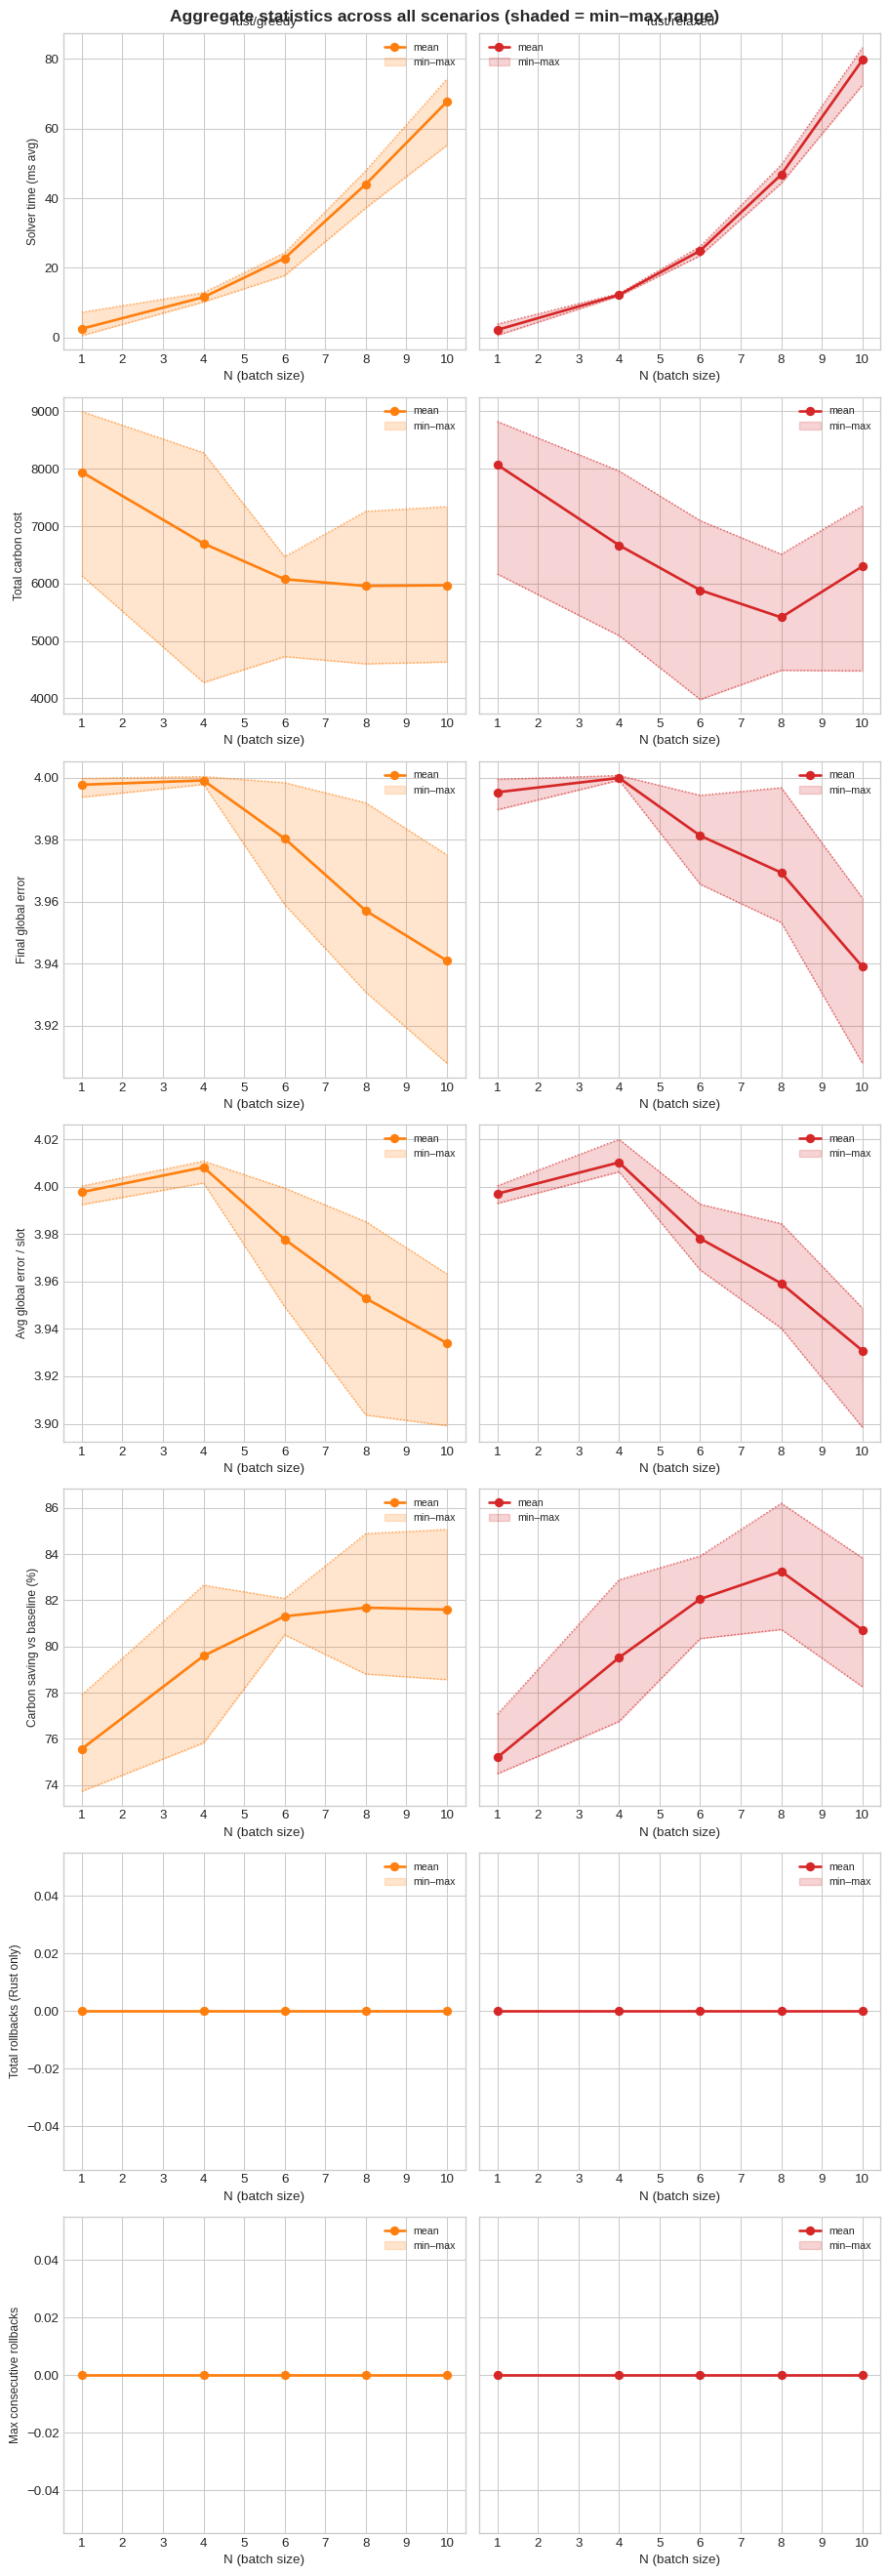

In [58]:
combos_sorted = sorted(combos)
fig_rows = len(METRICS)
fig_cols = len(combos_sorted)

fig, axes = plt.subplots(
    fig_rows, fig_cols,
    figsize=(4.8 * fig_cols, 4.0 * fig_rows),
    squeeze=False,
    sharey='row',
)
fig.suptitle("Aggregate statistics across all scenarios (shaded = min–max range)\n", fontsize=13, fontweight="bold")

for row, m in enumerate(METRICS):
    for col, (backend, mode) in enumerate(combos_sorted):
        ax = axes[row][col]
        sub = df[(df["backend"] == backend) & (df["infeasibility_mode"] == mode)]
        if sub.empty:
            ax.set_visible(False)
            continue
        grp = sub.groupby("batch_size")[m["col"]].agg(["min", "mean", "max"]).reset_index().sort_values("batch_size")
        xs = grp["batch_size"].values
        color = BACKEND_COLOR.get(backend, {}).get(mode, "gray")
        ax.plot(xs, grp["mean"], marker="o", linewidth=2.0, color=color, label="mean")
        ax.fill_between(xs, grp["min"], grp["max"], alpha=0.2, color=color, label="min–max")
        ax.plot(xs, grp["min"], linestyle=":", linewidth=1.0, color=color, alpha=0.7)
        ax.plot(xs, grp["max"], linestyle=":", linewidth=1.0, color=color, alpha=0.7)
        if row == 0:
            ax.set_title(_series_label(backend, mode), fontsize=10)
        if col == 0:
            ax.set_ylabel(m["label"], fontsize=9)
        ax.set_xlabel("N (batch size)")
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()


In [59]:
# Flat min/max/avg table (all N combined per backend+mode)
overall = (
    df.groupby(["backend", "infeasibility_mode"])[metric_cols]
    .agg(["min", "mean", "max"])
    .round(4)
)
print("Overall min / mean / max across ALL scenarios and ALL N values:")
overall


Overall min / mean / max across ALL scenarios and ALL N values:


solver_time_ms_avg                  \
                                          min    mean     max   
backend infeasibility_mode                                      
rust    greedy_fallback                0.6306 29.7293 74.1229   
        relaxed_retry                  0.6877 33.1782 83.1898   

                           total_carbon_cost                      \
                                         min      mean       max   
backend infeasibility_mode                                         
rust    greedy_fallback            4276.6447 6527.9390 8996.1980   
        relaxed_retry              3981.6025 6465.9585 8822.7228   

                           final_global_error                \
                                          min   mean    max   
backend infeasibility_mode                                    
rust    greedy_fallback                3.9079 3.9750 4.0003   
        relaxed_retry                  3.9078 3.9770 4.0007   

                           avg_global_error_per_slot                \
                                                 min   mean    max   
backend infeasibility_mode                                           
rust    greedy_fallback                       3.8992 3.9741 4.0108   
        relaxed_retry                         3.8985 3.9751 4.0200   

                           carbon_cost_saving_vs_baseline_pct                  \
                                                          min    mean     max   
backend infeasibility_mode                                                      
rust    greedy_fallback                               73.7310 79.9481 85.0688   
        relaxed_retry                                 74.4889 80.1460 86.2012   

                           total_rollbacks             \
                                       min   mean max   
backend infeasibility_mode                              
rust    greedy_fallback                  0 0.0000   0   
        relaxed_retry                    0 0.0000   0   

                           max_consecutive_rollbacks             
                                                 min   mean max  
backend infeasibility_mode                                       
rust    greedy_fallback                            0 0.0000   0  
        relaxed_retry                              0 0.0000   0